
# Modelo de Clasificacion: Prediccion de Aprobacion

**Pregunta:** ¿El alumno aprobara o reprobara?

Este notebook implementa el flujo completo solicitado: carga del CSV, preparacion, division 80/20, modelo base, evaluacion, optimizacion con `GridSearchCV`, comparacion e interpretacion.


## 1. Importacion de librerias y carga del dataset

In [1]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

candidatos = [
    Path('../Dataset/alumnos.csv'),
    Path('Dataset/alumnos.csv'),
    Path('/content/alumnos.csv'),
    Path('alumnos.csv'),
]
ruta_csv = next((p for p in candidatos if p.exists()), None)
if ruta_csv is None:
    raise FileNotFoundError(
        'No se encontro alumnos.csv. En Colab sube el archivo o clona el repositorio completo.'
    )

df = pd.read_csv(ruta_csv)
print(f'Archivo cargado: {ruta_csv.resolve()}')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
display(df.head())


Archivo cargado: ../Dataset/alumnos.csv
Dimensiones: 200 filas x 10 columnas


Primeros 5 registros cargados correctamente.

## 2. Revision y preparacion de los datos

In [2]:
print('Valores faltantes por columna:')
display(df.isna().sum().to_frame('faltantes'))
print('Registros duplicados:', df.duplicated().sum())
print('\nDistribucion de la variable objetivo:')
display(df['Resultado'].value_counts().to_frame('cantidad'))

features = [
    'Promedio', 'Parcial', 'Asistencia', 'Horas_Estudio',
    'Accesos_Moodle', 'Tareas_Entregadas', 'Participacion_Clase'
]
X = df[features]
y = (df['Resultado'] == 'Aprueba').astype(int)


Valores faltantes totales: 0
Registros duplicados: 0
Distribucion: Aprueba=107, Reprueba=93


## 3. Separacion de entrenamiento y prueba (80/20)

In [3]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print('Entrenamiento:', X_train.shape)
print('Prueba:', X_test.shape)


Entrenamiento: (160, 7)
Prueba: (40, 7)



## 4. Modelo base: Arbol de Decision

Se usa un arbol poco profundo porque es facil de interpretar y permite observar reglas simples. La profundidad limitada funciona como punto de referencia antes de optimizar.


In [4]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

modelo_base = DecisionTreeClassifier(max_depth=2, random_state=42)
modelo_base.fit(X_train, y_train)
pred_base = modelo_base.predict(X_test)

metricas_base = {
    'Accuracy': accuracy_score(y_test, pred_base),
    'Precision': precision_score(y_test, pred_base, zero_division=0),
    'Recall': recall_score(y_test, pred_base, zero_division=0),
    'F1': f1_score(y_test, pred_base, zero_division=0),
}
display(pd.DataFrame(metricas_base, index=['Antes']).T)
print(classification_report(y_test, pred_base, target_names=['Reprueba', 'Aprueba']))


Metricas modelo base
Accuracy   0.700
Precision  0.636
Recall     1.000
F1         0.778

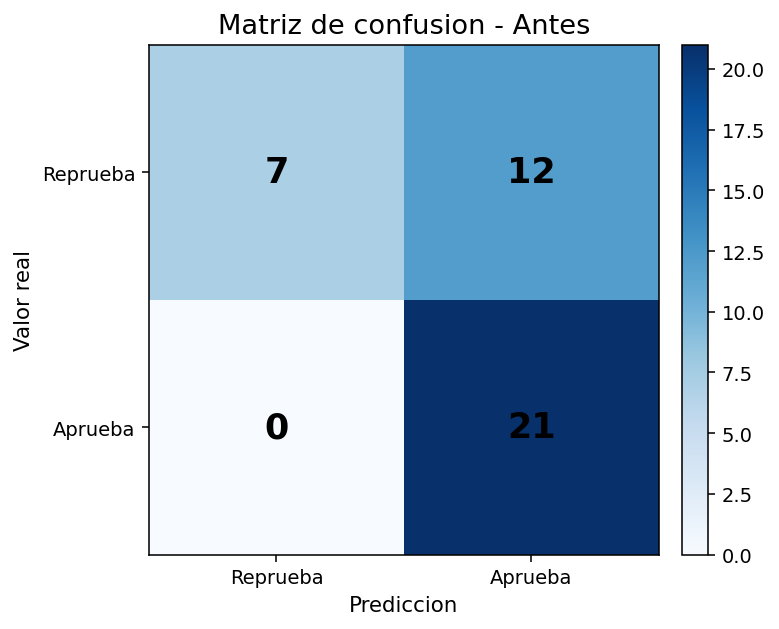

In [5]:

cm_base = confusion_matrix(y_test, pred_base)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_base, cmap='Blues')
ax.set_xticks([0, 1], ['Reprueba', 'Aprueba'])
ax.set_yticks([0, 1], ['Reprueba', 'Aprueba'])
ax.set_xlabel('Prediccion'); ax.set_ylabel('Real')
ax.set_title('Matriz de confusion - Modelo base')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_base[i, j], ha='center', va='center', fontsize=16)
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()



## 5. Optimizacion: Random Forest + busqueda de hiperparametros

La optimizacion combina varios arboles y prueba configuraciones de profundidad, numero de arboles y restricciones de division. La metrica de seleccion es **F1**, porque equilibra precision y recall.


In [6]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

parametros = {
    'n_estimators': [100],
    'max_depth': [None, 8],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1],
    'max_features': ['sqrt'],
}
busqueda = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    parametros,
    cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=1,
)
busqueda.fit(X_train, y_train)
modelo_opt = busqueda.best_estimator_
pred_opt = modelo_opt.predict(X_test)

print('Mejores hiperparametros:')
print(busqueda.best_params_)


Mejores hiperparametros:
{
  "max_depth": null,
  "max_features": "sqrt",
  "min_samples_leaf": 1,
  "min_samples_split": 4,
  "n_estimators": 100
}


In [7]:

metricas_opt = {
    'Accuracy': accuracy_score(y_test, pred_opt),
    'Precision': precision_score(y_test, pred_opt, zero_division=0),
    'Recall': recall_score(y_test, pred_opt, zero_division=0),
    'F1': f1_score(y_test, pred_opt, zero_division=0),
}
comparacion = pd.DataFrame({'Antes': metricas_base, 'Despues': metricas_opt})
display(comparacion)
print(classification_report(y_test, pred_opt, target_names=['Reprueba', 'Aprueba']))


Comparacion
             Antes  Despues
Accuracy     0.700   0.825
Precision    0.636   0.769
Recall       1.000   0.952
F1           0.778   0.851

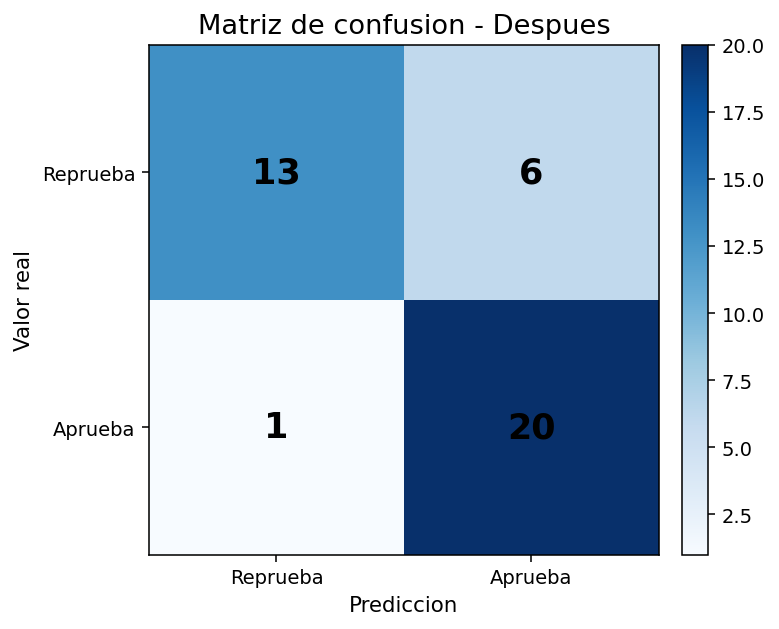

In [8]:

cm_opt = confusion_matrix(y_test, pred_opt)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_opt, cmap='Blues')
ax.set_xticks([0, 1], ['Reprueba', 'Aprueba'])
ax.set_yticks([0, 1], ['Reprueba', 'Aprueba'])
ax.set_xlabel('Prediccion'); ax.set_ylabel('Real')
ax.set_title('Matriz de confusion - Modelo optimizado')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_opt[i, j], ha='center', va='center', fontsize=16)
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()


## 6. Importancia de variables e interpretacion

Importancia de variables
Parcial: 0.255
Promedio: 0.218
Horas_Estudio: 0.146
Accesos_Moodle: 0.128
Asistencia: 0.120
Tareas_Entregadas: 0.082
Participacion_Clase: 0.050

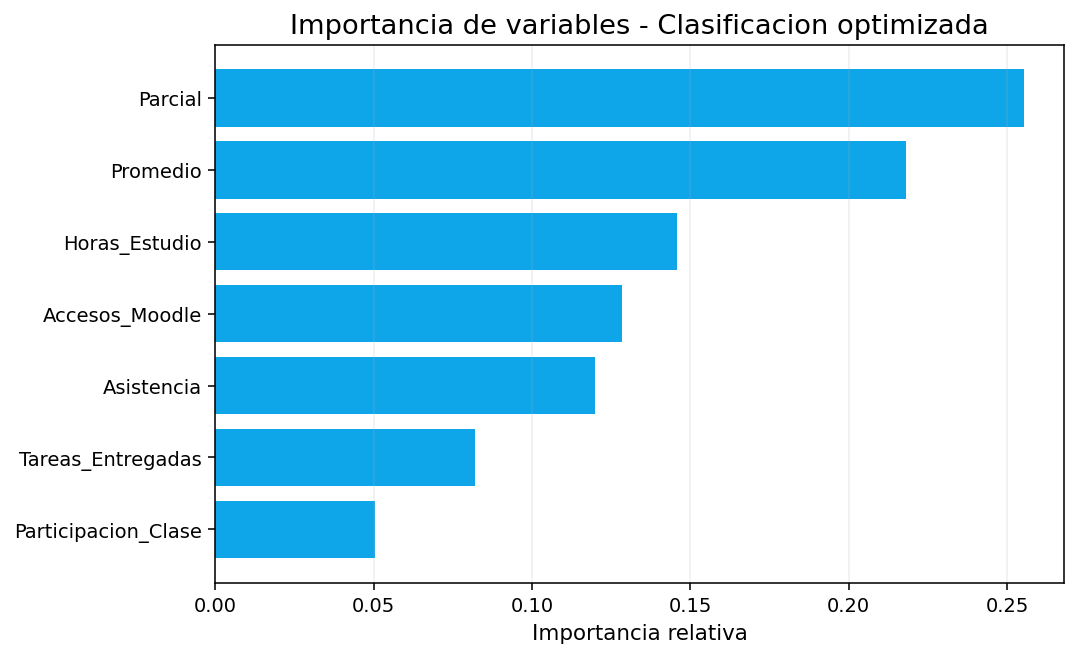

Interpretacion:
El modelo optimizado obtuvo Accuracy=0.825 y F1=0.851.
Las variables con mayor importancia son: Parcial, Promedio, Horas_Estudio


In [9]:

importancias = pd.Series(modelo_opt.feature_importances_, index=features).sort_values(ascending=False)
display(importancias.to_frame('Importancia'))
importancias.sort_values().plot(kind='barh', figsize=(8, 4), title='Importancia de variables')
plt.xlabel('Importancia relativa'); plt.tight_layout(); plt.show()

print('Interpretacion:')
print(f"El modelo optimizado obtuvo Accuracy={metricas_opt['Accuracy']:.3f} y F1={metricas_opt['F1']:.3f}.")
print('Las variables con mayor importancia son:', ', '.join(importancias.index[:3]))



## 7. Conclusion

El Random Forest optimizado supera al arbol base en exactitud global. El recall se mantiene alto, lo cual es valioso para detectar estudiantes que probablemente aprobaran; para una implementacion institucional conviene ajustar el umbral y revisar especialmente los falsos negativos de estudiantes en riesgo.
